# Donut bar chart (65+ prevalence)
Build country-level 65+ prevalence for three variables and plot donut chart with ISO3 labels.

In [1]:
# Paths
DATA_PATH = "../data/global40.dta"
BASE_DIR  = "../results/f1_donut"

import os
GLOBAL_DIR  = os.path.join(BASE_DIR)
os.makedirs(GLOBAL_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("GLOBAL_DIR:", GLOBAL_DIR)

DATA_PATH: ../data/global40.dta
GLOBAL_DIR: ../results/f1_donut


In [2]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DPI_OUT = 600
COLORS = {
    "rwalksa": "#4E9FCF",
    "rwalk1a": "#E16164",
    "rwalkra": "#8793A9",
}
print("OK: imports done.")

OK: imports done.


In [6]:
# Load & clean data
raw = pd.read_stata(DATA_PATH)
raw = (
    raw.assign(
        id=raw["id"].astype(str),
        age=pd.to_numeric(raw["ragey_b"], errors="coerce"),
        country=raw["isocountry_c"].astype(str),
        rwalksa=pd.to_numeric(raw.get("rwalksa"), errors="coerce"),
        rwalk1a=pd.to_numeric(raw.get("rwalk1a"), errors="coerce"),
        rwalkra=pd.to_numeric(raw.get("rwalkra"), errors="coerce"),
    )
    .loc[:, ["id", "age", "country", "rwalksa", "rwalk1a", "rwalkra"]]
    .dropna(subset=["id", "country", "age"])
    .loc[lambda d: d["country"].str.strip() != "", :]
)

for v in ["rwalksa", "rwalk1a", "rwalkra"]:
    raw[v] = raw[v].where(raw[v].isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())

raw shape: (1206788, 6)
countries: 40


In [7]:
# Build country-level 65+ prevalence for three variables
df65 = raw.loc[raw["age"].ge(65), ["country", "rwalksa", "rwalk1a", "rwalkra"]].copy()

country_65 = (
    df65.groupby("country", dropna=False)
    .agg(
        n=("rwalksa", "size"),
        rwalksa=("rwalksa", "mean"),
        rwalk1a=("rwalk1a", "mean"),
        rwalkra=("rwalkra", "mean"),
    )
    .reset_index()
    .dropna(subset=["country"])
 )

# Keep countries with at least 30 observations aged 65+
country_65 = country_65[country_65["n"] >= 30].copy()
country_65[["rwalksa", "rwalk1a", "rwalkra"]] = country_65[["rwalksa", "rwalk1a", "rwalkra"]].fillna(0.0)

# Map country name -> ISO3 using iso.csv
iso_path = "../data/iso40.csv"
iso_ref = pd.read_csv(iso_path)
iso_ref["isocountry_c"] = iso_ref["isocountry_c"].astype(str).str.strip()
iso_ref["iso3c"] = iso_ref["iso3c"].astype(str).str.strip()
iso_map = dict(zip(iso_ref["isocountry_c"], iso_ref["iso3c"]))
country_65["iso3"] = country_65["country"].astype(str).str.strip().map(iso_map)
country_65["iso3"] = country_65["iso3"].fillna(country_65["country"])

# Manual ISO3 overrides
manual_iso3 = {
    "Slovakia": "SVK",
    "Czech Republic": "CZE",
    "England": "GBR",
}
country_65["iso3"] = country_65.apply(
    lambda r: manual_iso3.get(r["country"], r["iso3"]),
    axis=1,
 )

DROP_COUNTRIES = ["Brazil", "Ireland", "South Africa", "Costa Rica"]
country_65_all = country_65.copy()
country_65_drop = country_65[~country_65["country"].isin(DROP_COUNTRIES)].copy()

country_65_all.head(40)

,country,n,rwalksa,rwalk1a,rwalkra,iso3
0,Australia,10627,0.000000,0.310889,0.000000,AUS
1,Austria,14127,0.000000,0.138733,0.035559,AUT
2,Belgium,17839,0.000000,0.176140,0.040056,BEL
3,Brazil,8974,0.484347,0.303782,0.091906,BRA
4,Bulgaria,2238,0.000000,0.223070,0.044144,BGR
5,China,23500,0.313118,0.132552,0.000000,CHN
6,Costa Rica,7594,0.447747,0.000000,0.139461,CRI
7,Croatia,6266,0.000000,0.198974,0.041098,HRV
8,Cyprus,1733,0.000000,0.263525,0.055879,CYP
9,Czech Republic,17764,0.000000,0.145405,0.035258,CZE


Saved donut chart to: ../results/f1_donut/donut.pdf


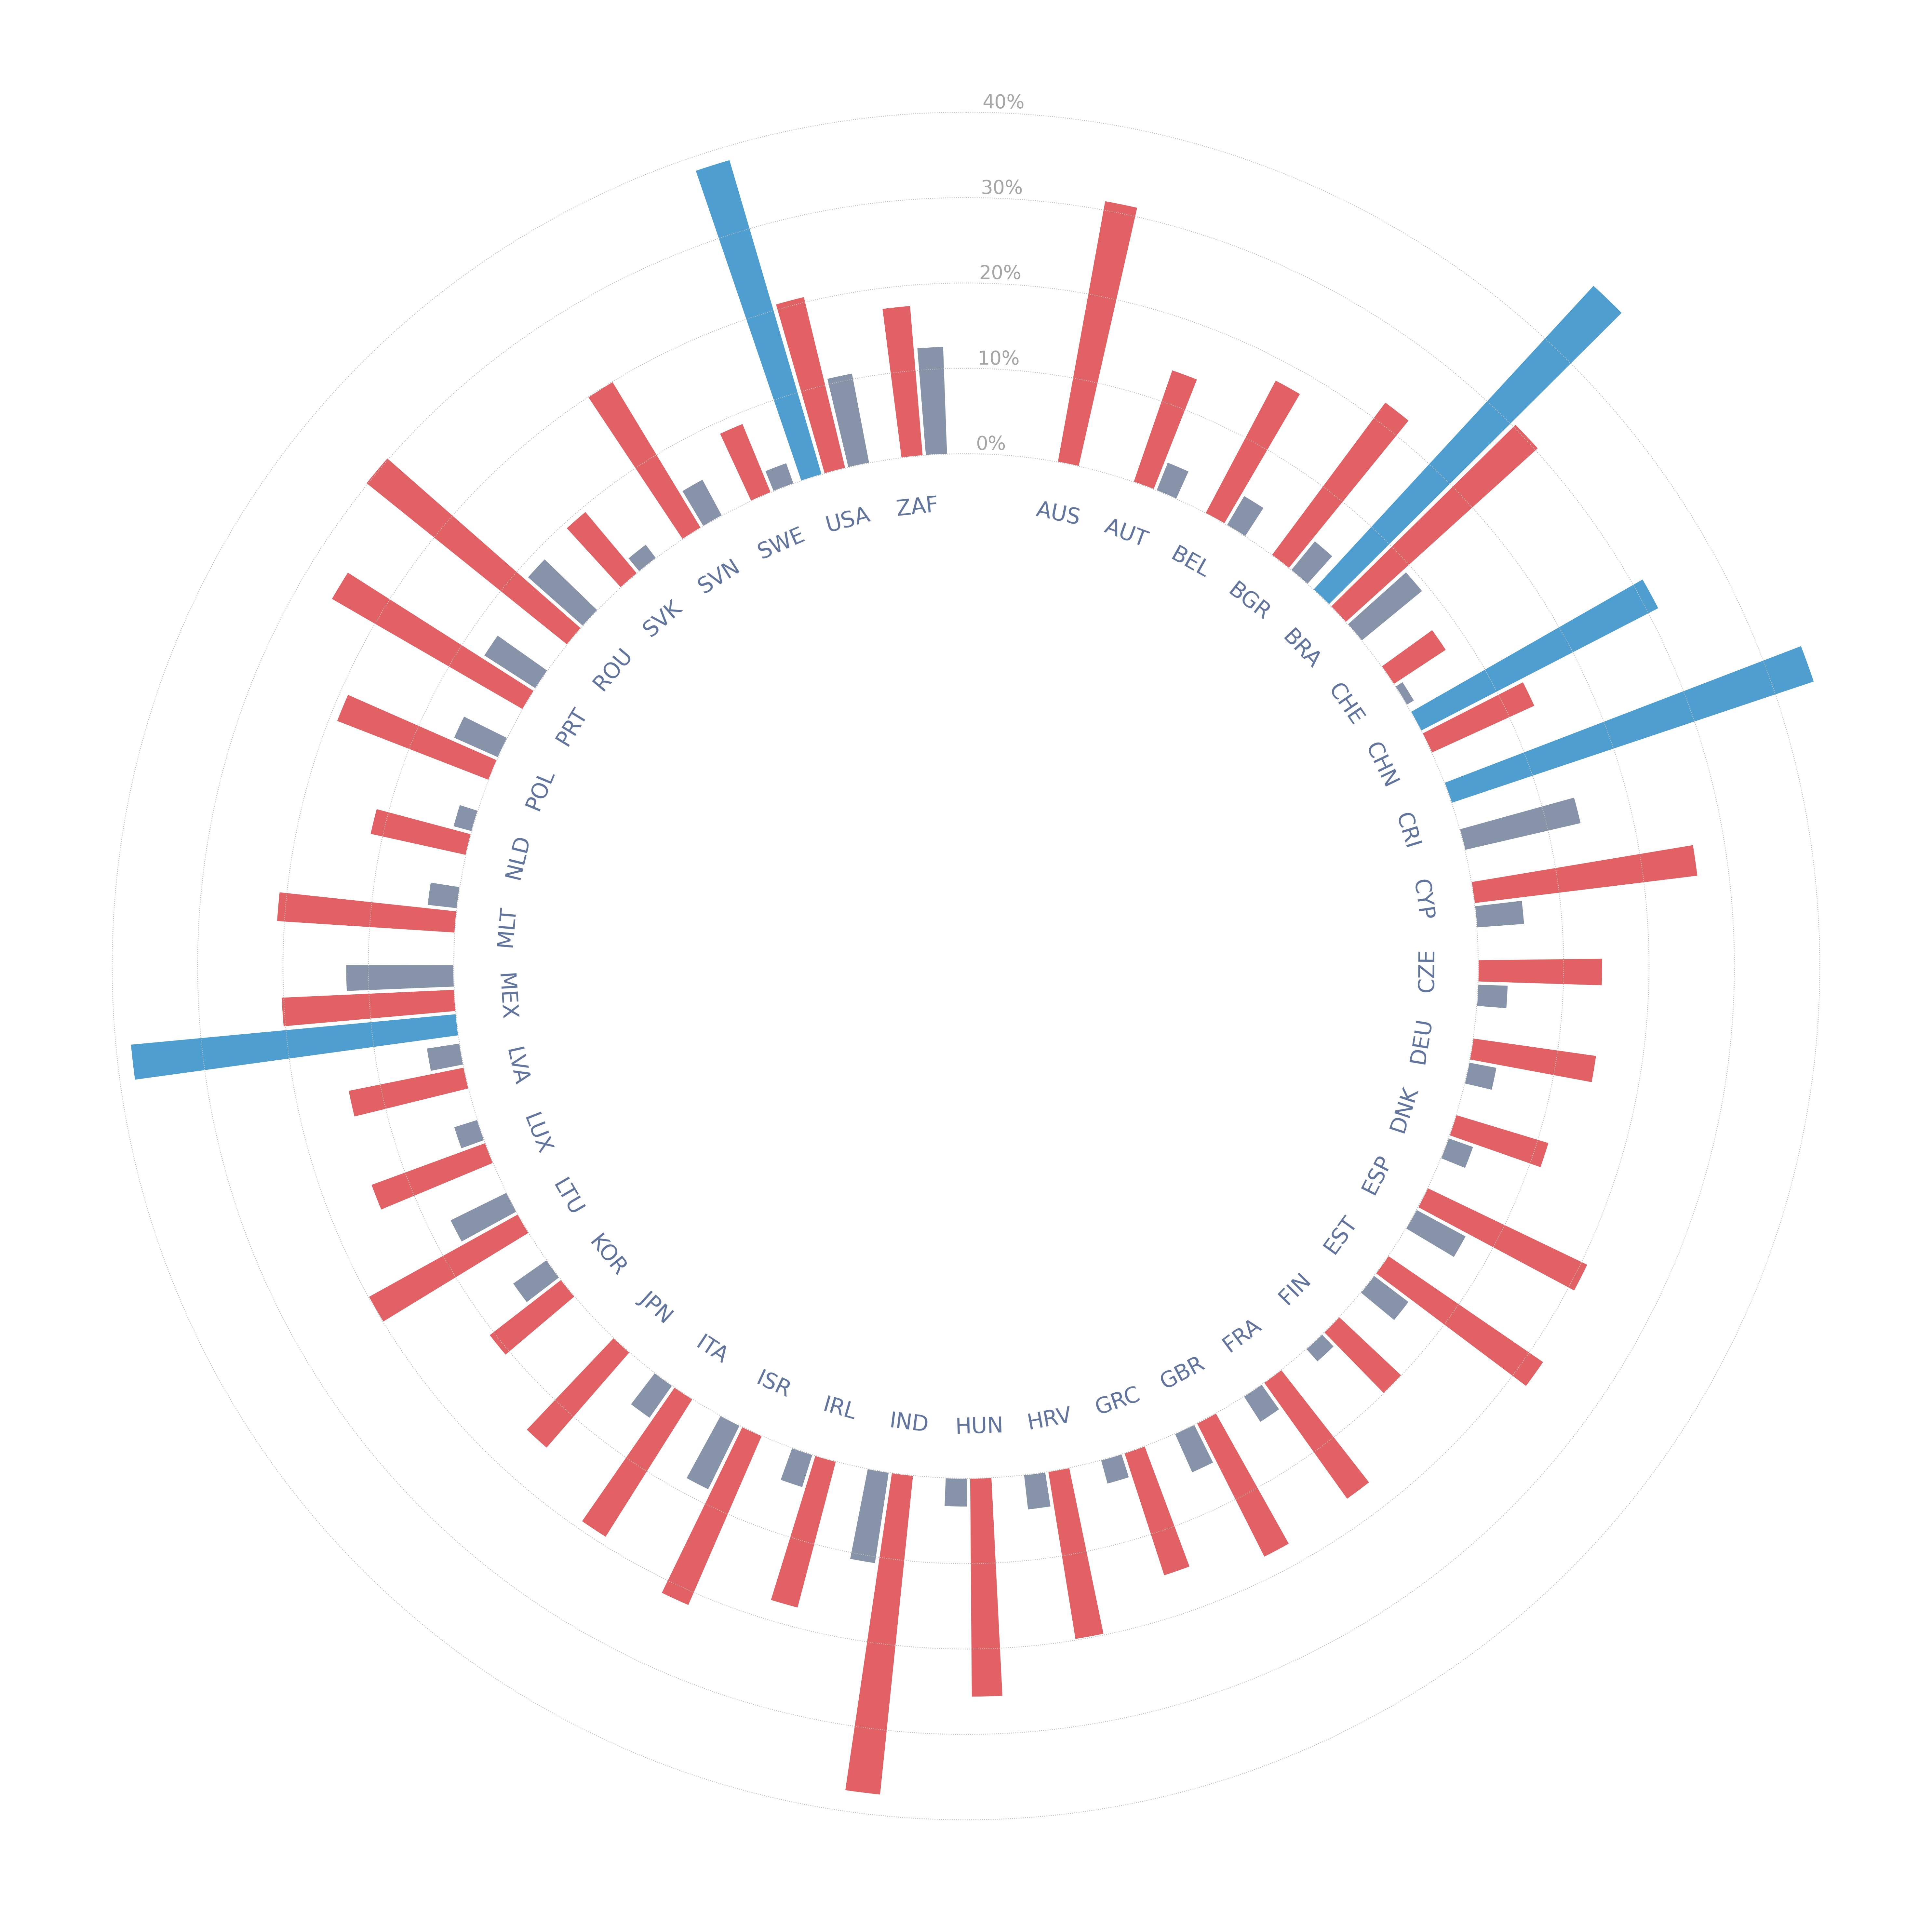

In [8]:
# Donut bar chart (countries grouped, ISO3 labels)
vars3 = ["rwalksa", "rwalk1a", "rwalkra"]
var_colors = {
    "rwalksa": COLORS["rwalksa"],
    "rwalk1a": COLORS["rwalk1a"],
    "rwalkra": COLORS["rwalkra"],
}

LABEL_FS = 8

def _polar_label(ax, angle, radius, text, color="black", fs=LABEL_FS):
    angle_deg = np.degrees(angle)
    screen_angle = 90 - angle_deg
    rotation = screen_angle - 90
    rotation = (rotation + 360) % 360
    if rotation > 180:
        rotation -= 360
    if not (-90 <= rotation <= 90):
        rotation += 180
    ax.text(
        angle,
        radius,
        text,
        rotation=rotation,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=fs,
        color=color,
    )

def plot_donut(df: pd.DataFrame, out_name: str) -> None:
    df = df.copy()
    df["iso3_initial"] = df["iso3"].astype(str).str[0].str.upper()
    country_order = df.sort_values(["iso3_initial", "iso3"]).reset_index(drop=True)
    n_c = country_order.shape[0]
    bar_gap = 0.01
    total_slots = n_c + 1
    bar_w = (2 * np.pi - total_slots * bar_gap) / (total_slots * len(vars3))
    r0 = 0.3
    scale = 0.50
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=600)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)

    theta_offset = len(vars3) * bar_w + bar_gap
    empty_mid = (len(vars3) * bar_w) / 2

    for i, row in country_order.iterrows():
        base = theta_offset + i * (len(vars3) * bar_w + bar_gap)
        for j, v in enumerate(vars3):
            ang = base + j * bar_w
            val = float(row[v])
            ax.bar(ang, val * scale, width=bar_w * 0.9, bottom=r0, color=var_colors[v], edgecolor="white", linewidth=0.3)
        mid_ang = base + (len(vars3) - 1) * bar_w / 2
        _polar_label(ax, mid_ang, r0 - 0.03, str(row["iso3"]), color="#60739C")

    ticks = [0.0, 0.1, 0.2, 0.3, 0.4]
    ax.set_yticks([r0 + t * scale for t in ticks])
    ax.set_yticklabels([f"{int(t * 100)}%" for t in ticks], fontsize=7, color="#A6A6A6")
    ax.set_rlabel_position(np.degrees(empty_mid) - 3)
    ax.set_xticks([])
    ax.grid(True, axis="y", color="#BCBCBC", linewidth=0.3, linestyle=":")
    ax.spines["polar"].set_visible(False)

    out_path = os.path.join(GLOBAL_DIR, out_name)
    fig.savefig(out_path, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
    print("Saved donut chart to:", out_path)
    fig.tight_layout()
    plt.show()

# donut34: drop the listed countries
# plot_donut(country_65_drop, "donut36.pdf")

# donut39: keep all countries (no filter)
plot_donut(country_65_all, "donut.pdf")

In [8]:
# Sample size by country and survey wave/year
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

SAMPLE_COUNT_COLS = ["id", "isocountry_c", "wave", "wave_year"]
sample_raw = pd.read_stata(DATA_PATH, columns=SAMPLE_COUNT_COLS)
sample_raw = sample_raw.assign(
    id=sample_raw["id"].astype(str),
    country=sample_raw["isocountry_c"].astype(str).str.strip(),
    wave=pd.to_numeric(sample_raw["wave"], errors="coerce"),
    wave_year=pd.to_numeric(sample_raw["wave_year"], errors="coerce"),
)
sample_raw = sample_raw.dropna(subset=["id", "country", "wave", "wave_year"])
sample_raw = sample_raw.loc[sample_raw["country"].ne(""), :]

# Count each respondent once per country-wave-year.
sample_counts = (
    sample_raw.drop_duplicates(["country", "wave", "wave_year", "id"])
    .groupby(["wave_year", "country"], as_index=False)
    .agg(n=("id", "size"), wave=("wave", "min"))
    .sort_values(["wave_year", "country"])
)
sample_counts["wave_year"] = sample_counts["wave_year"].astype(int)
sample_counts.to_csv(os.path.join(GLOBAL_DIR, "sample_size_by_country_wave.csv"), index=False)

plot_df = sample_counts.pivot_table(
    index="wave_year", columns="country", values="n", aggfunc="sum", fill_value=0
).sort_index()
country_totals = plot_df.sum(axis=0).sort_values(ascending=False)
plot_df = plot_df[country_totals.index]

country_names = list(plot_df.columns)
base_cmaps = [plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c]
country_colors = {}
for i, country in enumerate(country_names):
    cmap = base_cmaps[(i // 20) % len(base_cmaps)]
    country_colors[country] = cmap((i % 20) / 20)

fig, ax = plt.subplots(figsize=(18, 10), dpi=DPI_OUT)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(plot_df.index))
bottom = np.zeros(len(plot_df.index), dtype=float)
bar_width = 0.62
for country in country_names:
    values = plot_df[country].to_numpy(dtype=float)
    ax.bar(
        x,
        values,
        bottom=bottom,
        width=bar_width,
        color=country_colors[country],
        edgecolor="white",
        linewidth=0.25,
        label=country,
    )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in plot_df.index], fontsize=13, color="#555555", rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: "0" if v == 0 else f"{v/1000:.0f}k"))
ax.tick_params(axis="y", labelsize=13, colors="#555555", length=0)
ax.tick_params(axis="x", length=0)
ax.grid(axis="y", color="#E2E2E2", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#C9D3E3")
ax.spines["bottom"].set_linewidth(0.6)


legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=6.5,
           markerfacecolor=country_colors[c], markeredgecolor=country_colors[c], label=c)
    for c in country_names
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=8,
    frameon=False,
    fontsize=15,
    handlelength=1.0,
    handletextpad=0.5,
    columnspacing=1.4,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
out_pdf = os.path.join(GLOBAL_DIR, "sample_size_by_country_wave.pdf")
fig.savefig(out_pdf, dpi=DPI_OUT, bbox_inches="tight", facecolor="white", edgecolor="none")
print("Saved:", out_pdf)
print("Saved:", os.path.join(GLOBAL_DIR, "sample_size_by_country_wave.csv"))
plt.show()


Saved: ../results/f1_donut/sample_size_by_country_wave.pdf
Saved: ../results/f1_donut/sample_size_by_country_wave.csv
